In [1]:
import pandas as pd
import os
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    roc_curve, 
    auc, 
    precision_recall_curve,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
print(os.getcwd())
os.chdir('C:\\Users\\moham\\Downloads\\Projects\\Toxicity_Prediction\\Drymouth\\Datasets')
os.listdir()

c:\Users\moham\Downloads


['X_test_x.xlsx', 'X_train_x.xlsx', 'y_test_x.xlsx', 'y_train_x.xlsx']

In [3]:
x_train = pd.read_excel('X_train_x.xlsx')
x_test = pd.read_excel('X_test_x.xlsx')
y_train = pd.read_excel('y_train_x.xlsx')
y_test = pd.read_excel('y_test_x.xlsx')

### Model Pipeline

In [4]:
X_train_nn = x_train.copy()
X_test_nn = x_test.copy()
y_train_nn = y_train['Drymouth_binary']
y_test_nn = y_test['Drymouth_binary']

In [7]:
X_train_nn = X_train_nn.set_index("Patient")
X_test_nn = X_test_nn.set_index("Patient")

In [9]:
y_tr = np.ravel(y_train_nn.values)
y_te = np.ravel(y_test_nn.values)
X_tr_all = X_train_nn.values.astype('float32')      # DataFrame -> numpy (indexing ke liye)
X_te_all = X_test_nn.values.astype('float32')
n_in = X_tr_all.shape[1]

reg = regularizers.l1_l2(l1=1e-3, l2=1e-2)
def build_model():
    m = models.Sequential([
        layers.Input(shape=(n_in,)),
        layers.Dense(32, activation='relu', kernel_regularizer=reg),
        layers.Dropout(0.35),
        layers.Dense(16, activation='relu', kernel_regularizer=reg),
        layers.Dense(1,  activation='sigmoid')
    ])
    m.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return m

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tr_all, y_tr), 1):
    tf.keras.backend.clear_session()
    X_tr_f, X_va_f = X_tr_all[tr_idx], X_tr_all[va_idx]
    y_tr_f, y_va_f = y_tr[tr_idx], y_tr[va_idx]

    cls = np.unique(y_tr_f)
    cw  = dict(zip(cls, compute_class_weight('balanced', classes=cls, y=y_tr_f)))

    m = build_model()
    es = callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                 patience=20, restore_best_weights=True)
    m.fit(X_tr_f, y_tr_f,
          validation_data=(X_va_f, y_va_f),
          epochs=200, batch_size=16, class_weight=cw,
          callbacks=[es], verbose=0)

    auc_f = roc_auc_score(y_va_f, m.predict(X_va_f, verbose=0).ravel())
    fold_aucs.append(auc_f)
    print(f"Fold {fold}: val AUC = {auc_f:.3f}")

print(f"\nCV AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

tf.keras.backend.clear_session()
cls = np.unique(y_tr)
class_weight = dict(zip(cls, compute_class_weight('balanced', classes=cls, y=y_tr)))
print("class_weight:", class_weight)

model = build_model()                               
es = callbacks.EarlyStopping(monitor='val_auc', mode='max',
                             patience=20, restore_best_weights=True)
history = model.fit(                                  # name kept: 'history'
    X_tr_all, y_tr,
    validation_split=0.2,
    epochs=200, batch_size=16,
    class_weight=class_weight,
    callbacks=[es], verbose=0
)

loss, acc,tauc, rec = model.evaluate(X_te_all, y_te, verbose=1)
print(f"Test  acc: {acc:.3f}  AUC: {tauc:.3f}  recall: {rec:.3f}")


Fold 1: val AUC = 0.719
Fold 2: val AUC = 0.728
Fold 3: val AUC = 0.640
Fold 4: val AUC = 0.749
Fold 5: val AUC = 0.727

CV AUC: 0.713 ± 0.037
class_weight: {np.int64(0): np.float64(0.8333333333333334), np.int64(1): np.float64(1.25)}
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6387 - auc: 0.6767 - loss: 1.0308 - recall: 0.6809
Test  acc: 0.639  AUC: 0.677  recall: 0.681


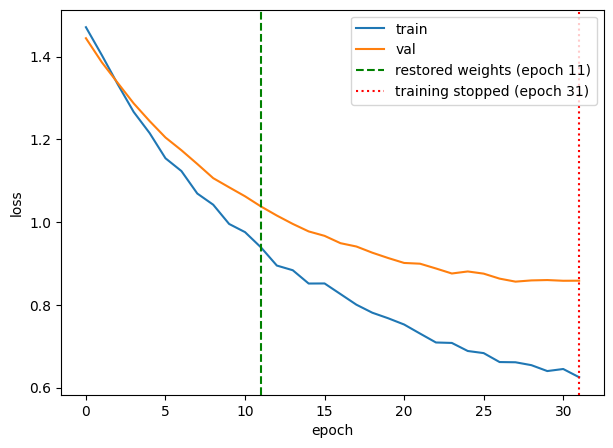

Best val_auc = 0.655 at epoch 11
val_loss at that epoch = 1.038


In [10]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
val_auc    = history.history['val_auc']

best_epoch = int(np.argmax(val_auc))   # weights restored from here (monitor=val_auc)
stop_epoch = len(val_loss) - 1         # last epoch actually trained

plt.figure(figsize=(7,5))
plt.plot(train_loss, label='train')
plt.plot(val_loss,   label='val')

# vertical line at the restored (best-AUC) epoch
plt.axvline(best_epoch, color='green', ls='--',
            label=f'restored weights (epoch {best_epoch})')
# optional: where training actually stopped
plt.axvline(stop_epoch, color='red', ls=':',
            label=f'training stopped (epoch {stop_epoch})')

plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()
print(f"Best val_auc = {val_auc[best_epoch]:.3f} at epoch {best_epoch}")
print(f"val_loss at that epoch = {val_loss[best_epoch]:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


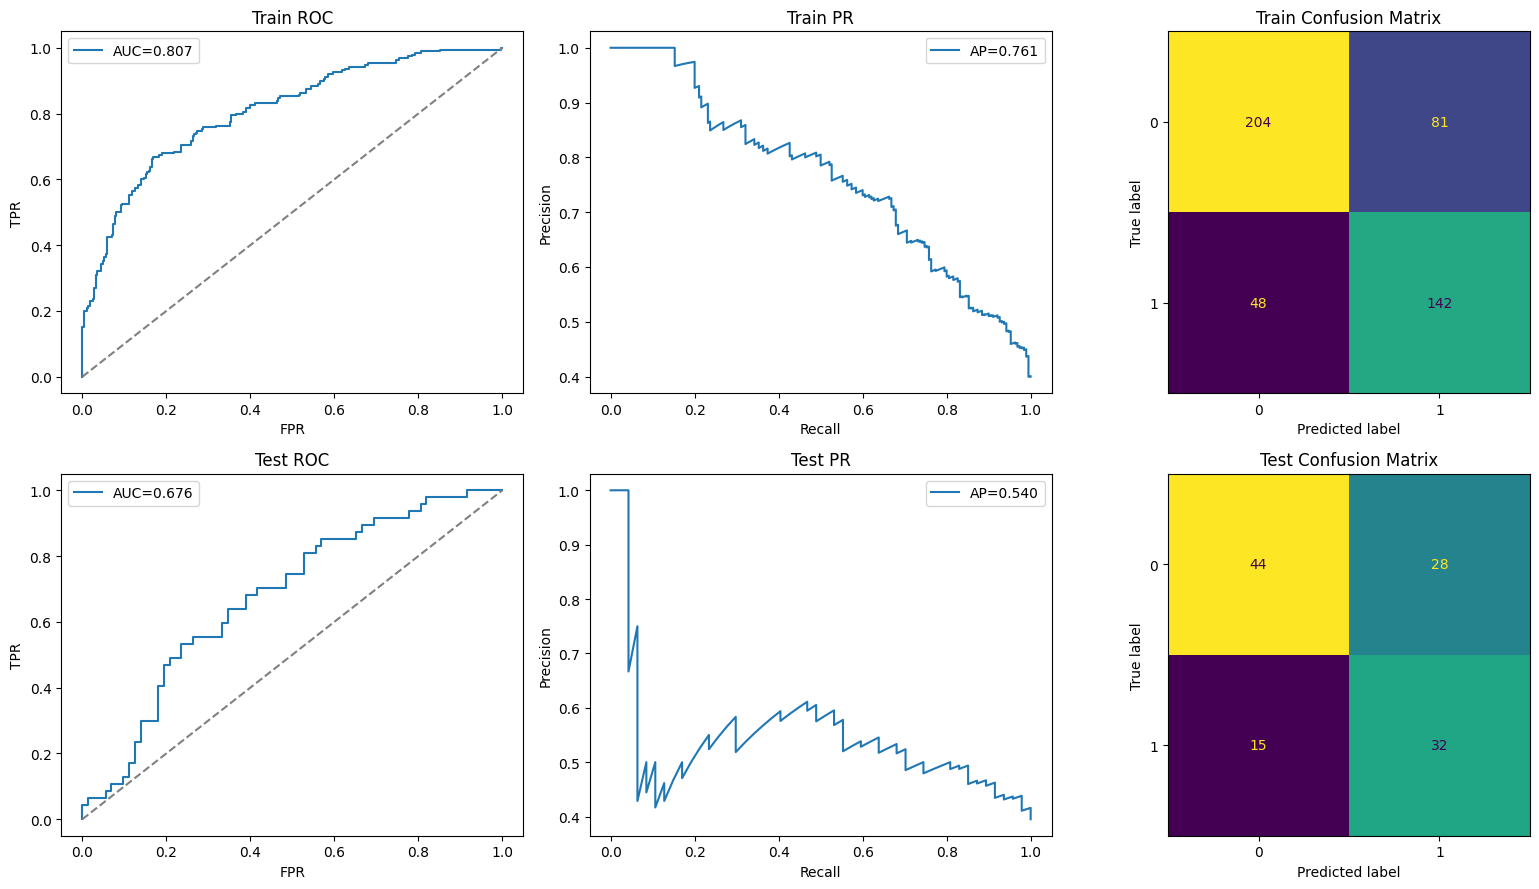

In [12]:
train_probs = model.predict(X_tr_all).flatten()
test_probs  = model.predict(X_te_all).flatten()

ytr = y_tr
yte = y_te

fig, ax = plt.subplots(2, 3, figsize=(16, 9))
for r, (name, yt, pr) in enumerate([('Train', ytr, train_probs),
                                    ('Test', yte, test_probs)]):
    fpr, tpr, _ = roc_curve(yt, pr)
    ax[r,0].plot(fpr, tpr, label=f'AUC={auc(fpr,tpr):.3f}')
    ax[r,0].plot([0,1],[0,1],'--',c='gray')
    ax[r,0].set_title(f'{name} ROC'); ax[r,0].set_xlabel('FPR'); ax[r,0].set_ylabel('TPR'); ax[r,0].legend()

    pc, rc, _ = precision_recall_curve(yt, pr)
    ax[r,1].plot(rc, pc, label=f'AP={auc(rc,pc):.3f}')
    ax[r,1].set_title(f'{name} PR'); ax[r,1].set_xlabel('Recall'); ax[r,1].set_ylabel('Precision'); ax[r,1].legend()

    cm = confusion_matrix(yt, (pr>=0.5).astype(int))
    ConfusionMatrixDisplay(cm).plot(ax=ax[r,2], colorbar=False)
    ax[r,2].set_title(f'{name} Confusion Matrix')

results_dir = r"C:\Users\moham\Downloads\Projects\Toxicity_Prediction\Drymouth\Results"

os.makedirs(results_dir, exist_ok=True)

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "NN_Performance_Xerostomia.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()